# Numpy 과제 #2
### KDT 12기 이재헌
#### 이미지 처리

In [1]:
import numpy as np
from PIL import Image
import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

##### * Lenna 이미지를 읽어서 numpy의 배열로 저장 및 화면 출력

(512, 512, 3)


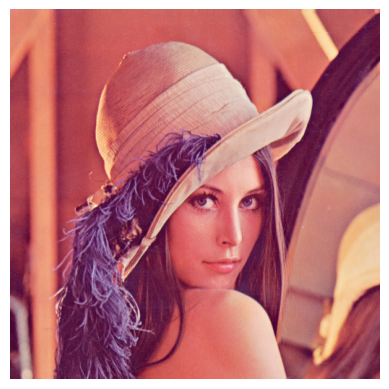

In [2]:
img = Image.open('Lenna.png')
img_array = np.array(img)

print(img_array.shape)
plt.imshow(img_array)
plt.axis('off')
plt.show()

##### * image_array 배열에서 원본, Red, Green, Blue 채널의 데이터만 읽어서 각 데이터를 subplot 그래프로 출력

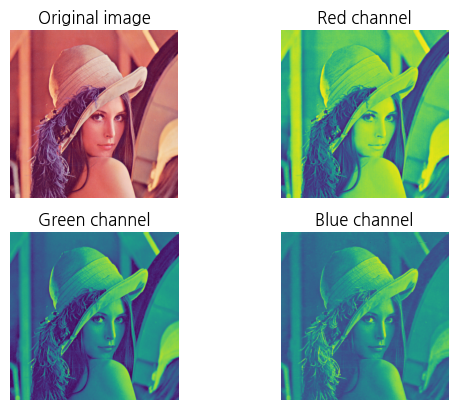

In [3]:
r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
img_red = (r + 0 * g + 0 * b).astype(np.uint8)
img_green = (0 * r + g + 0 * b).astype(np.uint8)
img_blue = (0 * r + 0 * g +  b).astype(np.uint8)

plt.subplot(2,2,1) # 2행 2열 중 첫번째
plt.imshow(img_array)
plt.axis('off')
plt.title('Original image')

plt.subplot(2,2,2) # 2행 2열 중 두번째
plt.imshow(img_red)
plt.axis('off')
plt.title('Red channel')

plt.subplot(2,2,3) # 2행 2열 중 세번째
plt.imshow(img_green)
plt.axis('off')
plt.title('Green channel')

plt.subplot(2,2,4) # 2행 2열 중 네번째
plt.imshow(img_blue)
plt.axis('off')
plt.title('Blue channel')

plt.show()

##### * 이미지 데이터를 깊은 복사 수행 후 RGB 색상 중 Red, Green, Blue 데이터만 화면에 출력

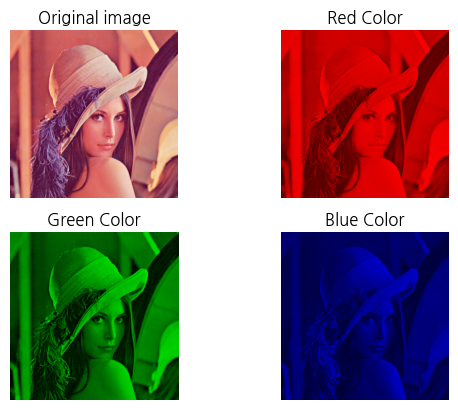

In [4]:
copy_img_red = img_array.copy()
copy_img_red[:,:,1] = 0
copy_img_red[:,:,2] = 0

copy_img_green = img_array.copy()
copy_img_green[:,:,0] = 0
copy_img_green[:,:,2] = 0

copy_img_blue = img_array.copy()
copy_img_blue[:,:,0] = 0
copy_img_blue[:,:,1] = 0


plt.subplot(2,2,1) # 2행 2열 중 첫번째
plt.imshow(img_array)
plt.axis('off')
plt.title('Original image')

plt.subplot(2,2,2) # 2행 2열 중 두번째
plt.imshow(copy_img_red)
plt.axis('off')
plt.title('Red Color')

plt.subplot(2,2,3) # 2행 2열 중 세번째
plt.imshow(copy_img_green)
plt.axis('off')
plt.title('Green Color')

plt.subplot(2,2,4) # 2행 2열 중 네번째
plt.imshow(copy_img_blue)
plt.axis('off')
plt.title('Blue Color')

plt.show()

##### * 반전 이미지 출력

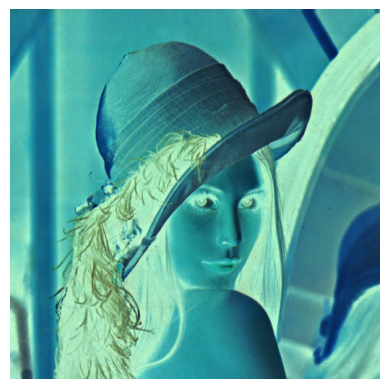

In [10]:
x = np.array([0,0,0])
invert_img = np.add(x,- img_array)
plt.imshow(invert_img)
plt.axis('off')
plt.show()
# 이 값에서 x에 0이 들어가야 나오는 이유 : 원래 값에서 (-)를 줘버리면 uint8의 범위(0~255)를 넘어가 오버플로우가 발생한다.
# 그래서 프로그램이 자동으로 범위값인 256을 더해 정상 범위 안으로 되돌리려고 한다.
# 따라서 (-)를 줘버린 결과값 그대로가 반전 이미지처럼 출력되게 되는 것이다.
# 하지만 정확하게 반전 이미지는 아니다. 
# 같으려면 np.array_equal(np.add(x, -img_array), 255 - img_array) 이 True를 만족해야 하는데 False가 나온다.
# 그 이유는 원래의 픽셀값이 1~255였을 때는 차이가 1이 나기 때문이다.(0에서는 차이 없음)
# 예) 픽셀값 : 100 // 상황1) 255-100 = 155, 상황2) add(0, -100) -> (오버플로우) -> "256" - 100 = 156

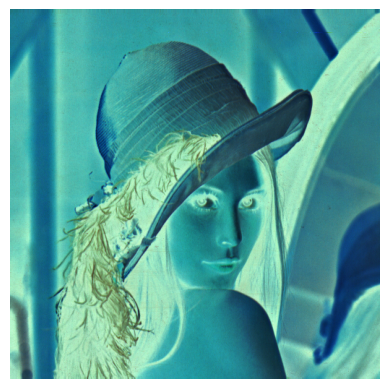

In [5]:
invert_img = 255 - img_array
plt.imshow(invert_img)
plt.axis('off')
plt.show()

##### * 밝기 증가 및 감소 후 2개의 이미지 출력

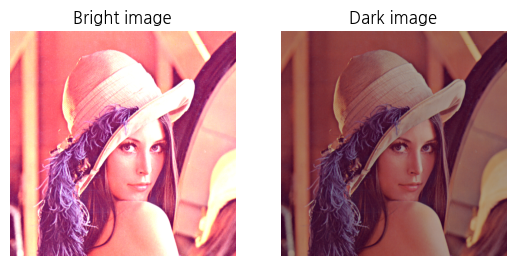

In [6]:
bright_img = np.clip((img_array * 1.5), 0, 255).astype(int)
dark_img = np.clip((img_array * 0.7), 0, 255).astype(int)

plt.subplot(1,2,1)
plt.imshow(bright_img)
plt.axis('off')
plt.title('Bright image')

plt.subplot(1,2,2)
plt.imshow(dark_img)
plt.axis('off')
plt.title('Dark image')

plt.show()

##### * 이미지 좌우 반전 및 상하 반전

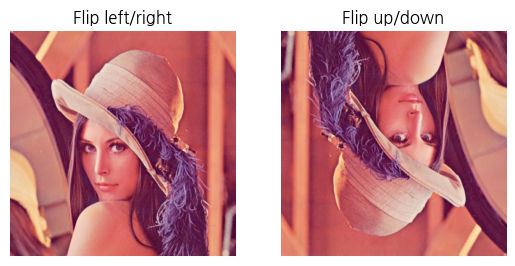

In [7]:
flip_lr_img = np.fliplr(img_array).astype(int)
flip_ud_img = np.flipud(img_array).astype(int)

plt.subplot(1,2,1)
plt.imshow(flip_lr_img)
plt.axis('off')
plt.title('Flip left/right')

plt.subplot(1,2,2)
plt.imshow(flip_ud_img)
plt.axis('off')
plt.title('Flip up/down')

plt.show()

##### * 2차원 배열을 1차원 배열로 변환 후 히스토그램 작성

[226 137 125 ... 185  74  81]


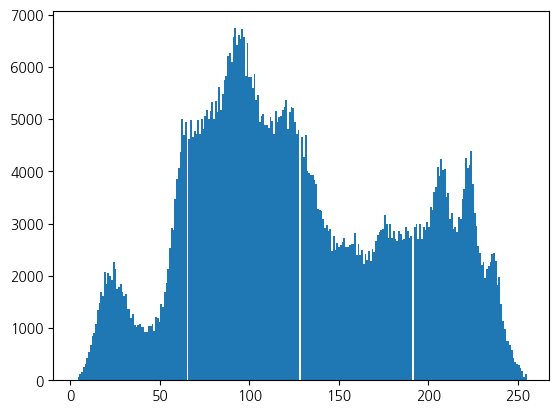

In [8]:
img_hist = img_array.flatten()
print(img_hist)



plt.hist(img_hist, bins=256)
plt.show()